In [1]:
# Importing required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Loading Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [3]:
df.shape

(150, 5)

In [4]:
# Checking unique target classes
df["target"].unique()

array([0, 1, 2])

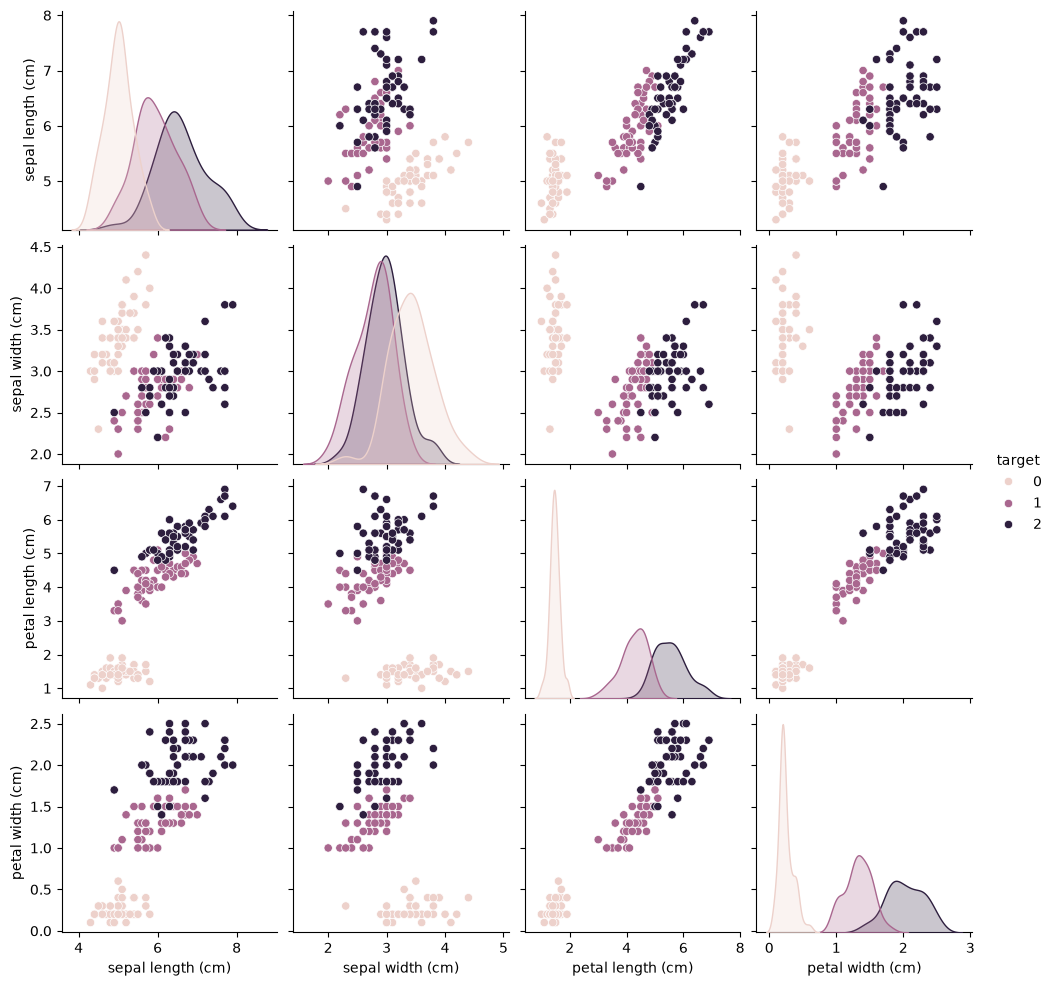

In [5]:
# Data Visualization (Before PCA) using Pairplot
sns.pairplot(df, hue="target")
plt.show()

In [6]:
# Feature Standardization (PCA requires centered and scaled data based on variance)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Mean:", np.mean(X_scaled, axis=0))
print("Standard deviation:", np.std(X_scaled, axis=0))

Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Standard deviation: [1. 1. 1. 1.]


In [8]:
# Applying Initial PCA Model
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("New data shape:", X_pca.shape)

New data shape: (150, 4)


In [9]:
# Evaluating Explained Variance Ratio (Scree Plot Analysis)
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

Explained variance ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]


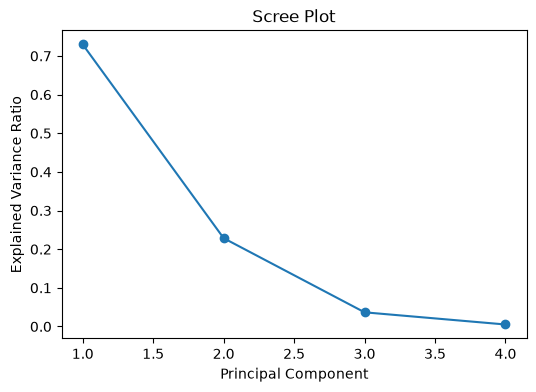

In [10]:
# Plotting Scree Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 5), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

In [12]:
# Reducing Dimensions to 2 Components (4D -> 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


In [13]:
# Visualizing Data After PCA Projection
pca_df = pd.DataFrame()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]
pca_df["target"] = y

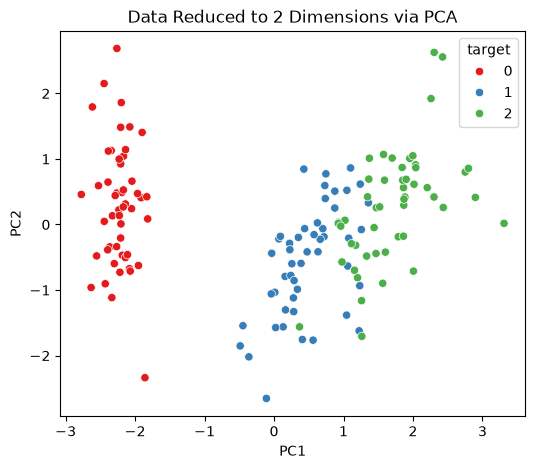

In [14]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="target",
    data=pca_df,
    palette="Set1"
)
plt.title("Data Reduced to 2 Dimensions via PCA")
plt.show()

In [15]:
# Extracting PCA Component Loadings
components = pca.components_

print("PCA Components (Loadings):")
print(components)

PCA Components (Loadings):
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
